# Personal Information
Name: **Floor Verkade**

StudentID: **14615215**

Email: [**floor.verkade@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **23.03.2026**

# Data Context
This research uses two main datasets to create a specialised knowledge base for the RAG framework: official legislation and judicial rulings. The first dataset comprises the consolidated text of the Environment and Planning Act (Omgevingswet), identified as BWBR0037885. This data was retrieved from the Dutch government’s official portal (wetten.overheid.nl) in XML format. This dataset provides the normative foundation of the system by offering the legal rules that govern the physical living environment in the Netherlands.

The second dataset comprises legal judgments retrieved from the Open Rechtspraak REST API (data.rechtspraak.nl). This corpus includes administrative law cases specifically filtered for the "Omgevingswet" domain. Each entry provides the full-text judicial reasoning and official metadata, including the European Case Law Identifier (ECLI). By combining these interpretive rulings with the underlying legislative articles, the dataset provides a dual-layered context. This allows the RAG-system to not only retrieve factual information but also generate normative legal justifications by tracing how statutory rules are being applied by the courts in the context of the City of Amsterdam.

# Data Description

In [55]:
# Imports
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# only first time
# nltk.download('stopwords')

### 1. Data Loading

#### 1.1 Jurisprudence

In [56]:
# path for the jurisprudence corpus
jurisprudence_path = 'jurisprudence_omgevingswet.jsonl'

# load JSONL into DataFrame
jur_data = []
with open(jurisprudence_path, 'r', encoding='utf-8') as f:
    for line in f:
        jur_data.append(json.loads(line))

df_jurisprudence = pd.DataFrame(jur_data)
print(f"Jurisprudence dataset shape: {df_jurisprudence.shape}")
print(f"Columns: {df_jurisprudence.columns.tolist()}")


Jurisprudence dataset shape: (3906, 5)
Columns: ['ecli', 'title', 'updated', 'summary', 'full_text']


#### 1.2 Legalisation

In [57]:
# path for the legislation corpus
legislation_path = 'legislation_omgevingswet.jsonl'

# load JSONL into DataFrame
leg_data = []
with open(legislation_path, 'r', encoding='utf-8') as f:
    for line in f:
        leg_data.append(json.loads(line))

df_legislation = pd.DataFrame(leg_data)
print(f"Legislation dataset shape: {df_legislation.shape}")
print(f"Columns: {df_legislation.columns.tolist()}")


Legislation dataset shape: (725, 4)
Columns: ['source_type', 'id', 'title', 'text']


### 2. Data Transformation

In [58]:
# Calculate word counts
df_legislation['word_count'] = df_legislation['text'].apply(lambda x: len(str(x).split()))
df_jurisprudence['word_count'] = df_jurisprudence['full_text'].apply(lambda x: len(str(x).split()))

# Extract Court Instance from ECLI 
df_jurisprudence['court'] = df_jurisprudence['ecli'].str.split(':').str[2]

# Make year-column of the updated date for time analysis
df_jurisprudence['year'] = pd.to_datetime(df_jurisprudence['updated']).dt.year

### 3. Data cleaning & integrity
To ensure the reliability of the RAG system, a data integrity check was performed. The focus was on missing values in text columns and duplicate identifiers (ECLI for cases and ID for legislation), as these could lead to redundant or failed retrievals.

In [59]:
# Check for missing values
print("Missing Values")
print("Legislation:\n", df_legislation.isnull().sum())
print("\nJurisprudence:\n", df_jurisprudence.isnull().sum())

# Check for duplicates
print("\n Duplicates")
print(f"Duplicate ECLI's: {df_jurisprudence.duplicated(subset=['ecli']).sum()}")
print(f"Duplicate Article IDs: {df_legislation.duplicated(subset=['id']).sum()}")

Missing Values
Legislation:
 source_type    0
id             0
title          0
text           0
word_count     0
dtype: int64

Jurisprudence:
 ecli          0
title         0
updated       0
summary       0
full_text     0
word_count    0
court         0
year          0
dtype: int64

 Duplicates
Duplicate ECLI's: 0
Duplicate Article IDs: 0


#### 3.1 Data integrity findings
The initial cleaning and integrity check confirms the high quality of the raw data. Firstly, there are no missing values in the primary content columns ('text' for legislation and 'full_text' for jurisprudence) or identifiers. This ensures that the RAG retriever will not encounter empty documents that could degrade performance. Secondly, the absence of duplicate ECLIs and article IDs confirms that each record in the corpus represents a unique legal or judicial entity. This prevents the vector database from storing redundant information, which could lead to biased retrieval results. Thirdly, no data records were removed during this phase as the source datasets were already correct. The corpus remains at its original size of 725 legislative articles and 3,906 judicial rulings.

#### 3.2 Anomaly detection
In addition to missing values, empty records must be identified. In legal datasets, very short documents often represent procedural noise, such as simple administrative corrections, rather than substantive judicial reasoning. These anomalies are identified using a threshold of 50 words.

In [60]:
# Identify potential anomalies based on word count
short_docs = df_jurisprudence[df_jurisprudence['word_count'] < 50]

print(f"Number of potential anomalies (documents < 50 words): {len(short_docs)}")

if len(short_docs) > 0:
    print("\nExamples of identified anomalies:")
    display(short_docs[['ecli', 'word_count', 'full_text']].head())

Number of potential anomalies (documents < 50 words): 502

Examples of identified anomalies:


,ecli,word_count,full_text
10,ECLI:NL:RBZWB:2024:94,3,Content not available
11,ECLI:NL:RBMNE:2024:9,3,Content not available
22,ECLI:NL:RBOVE:2024:498,3,Content not available
23,ECLI:NL:RVS:2024:380,3,Content not available
34,ECLI:NL:RBGEL:2024:418,3,Content not available


In [61]:
# Identify potential anomalies: Documents where content is missing or placeholder text
# Check for the specific placeholder "Content not available"
placeholders = df_jurisprudence[df_jurisprudence['full_text'].str.contains("Content not available", case=False)]

print(f"Number of documents with content not available: {len(placeholders)}")

# Show the ECLIs of these anomalies
print("\nECLIs of identified anomalies:")
print(anomalies[['ecli', 'full_text']].head())

Number of documents with content not available: 502

ECLIs of identified anomalies:
                      ecli              full_text
10   ECLI:NL:RBZWB:2024:94  Content not available
11    ECLI:NL:RBMNE:2024:9  Content not available
22  ECLI:NL:RBOVE:2024:498  Content not available
23    ECLI:NL:RVS:2024:380  Content not available
34  ECLI:NL:RBGEL:2024:418  Content not available


##### 3.2.1 Anomalies findings
A significant anomaly was identified in the substantive content of the jurisprudence dataset. A total of 502 records were found to contain the placeholder string: 'Content not available' instead of the actual judicial ruling. These anomalies are likely the result of missing data in the source API or restrictions on the automated retrieval of sensitive cases.

#### 3.3 Cleaning data
Here the rows containing content not available in the jurisprudence data are removed.

In [62]:
# Cleaning the dataset: removing the identified anomalies
df_jurisprudence_cleaned = df_jurisprudence[df_jurisprudence['full_text'] != "Content not available"].reset_index(drop=True)

print(f"Original Jurisprudence size: {len(df_jurisprudence)}")
print(f"Cleaned Jurisprudence size: {len(df_jurisprudence_cleaned)}")

df_jurisprudence = df_jurisprudence_cleaned

Original Jurisprudence size: 3906
Cleaned Jurisprudence size: 3404


##### 3.3.1 Explaination data cleaning
Rows containing 'Content not available' have been removed from the jurisprudence data. This step is necessary for the RAG framework, as these rows (502) were removed. This ensures that the vector store only contains substantive legal content and prevents the model from retrieving non-informative placeholders during the justification process.

### 4. Content anaylsis
#### 4.1 Document lengths
The distribution of word counts is analysed to determine the necessity of a chunking strategy. The difference in scale between legislation and jurisprudence is a key factor in the RAG architecture.


In [63]:
# text length analysis 
stats = pd.DataFrame({
    'Jurisprudence (Words)': df_jurisprudence['word_count'].describe(),
    'Legislation (Words)': df_legislation['word_count'].describe()
})

print("Descriptive Statistics for Word Counts:")
print(stats.round(2))

Descriptive Statistics for Word Counts:
       Jurisprudence (Words)  Legislation (Words)
count                3404.00               725.00
mean                 2591.66               110.53
std                  2206.76                82.80
min                   170.00                10.00
25%                  1504.00                50.00
50%                  2210.50                85.00
75%                  3099.50               152.00
max                 53109.00               591.00


The descriptive statistics reveal a significant structural difference between the two corpora. While the Legislation dataset is highly consistent and structured (mean = 111 words), the Jurisprudence dataset is significantly more complex and extensive (mean = 2,259 words). 

The high standard deviation in the Jurisprudence dataset (σ = 2,234.84) and maximum value of over 53,000 words suggest that court rulings contain in-depth, multi-layered legal reasoning. This necessitates a more sophisticated retrieval strategy than is required for the relatively 'atomic' legislative articles.

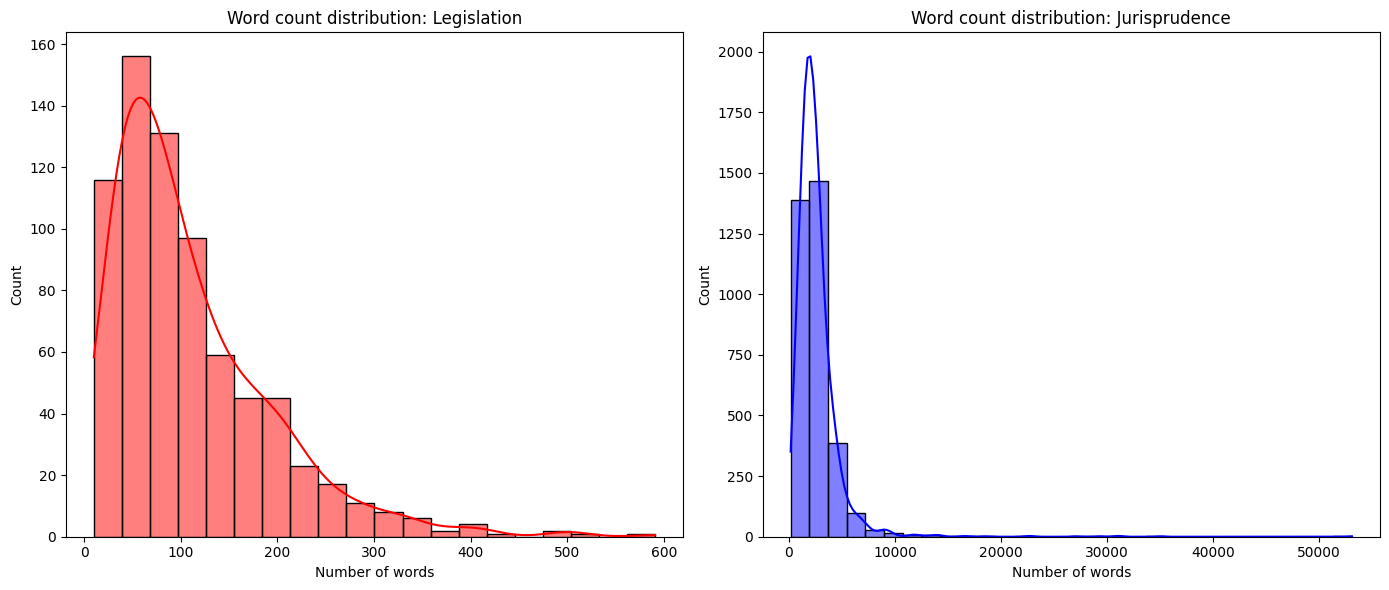

In [64]:
# distribution histograms
plt.figure(figsize=(14, 6))

# Legislation distribution
plt.subplot(1, 2, 1)
sns.histplot(df_legislation['word_count'], kde=True, color='red', bins=20)
plt.title('Word count distribution: Legislation')
plt.xlabel('Number of words')

# Jurisprudence distribution
plt.subplot(1, 2, 2)
sns.histplot(df_jurisprudence['word_count'], kde=True, color='blue', bins=30)
plt.title('Word count distribution: Jurisprudence')
plt.xlabel('Number of words')

plt.tight_layout()

The visual distribution confirms that legislation follows a near-normal distribution at a small scale, making it ideal for direct indexing. Conversely, jurisprudence exhibits a heavy-tailed (right-skewed) distribution.

While most court cases cluster between 1,000 and 3,000 words, the long tail represents complex environmental disputes requiring sliding-window chunking to prevent relevant legal nuances from being lost during the vectorisation process.

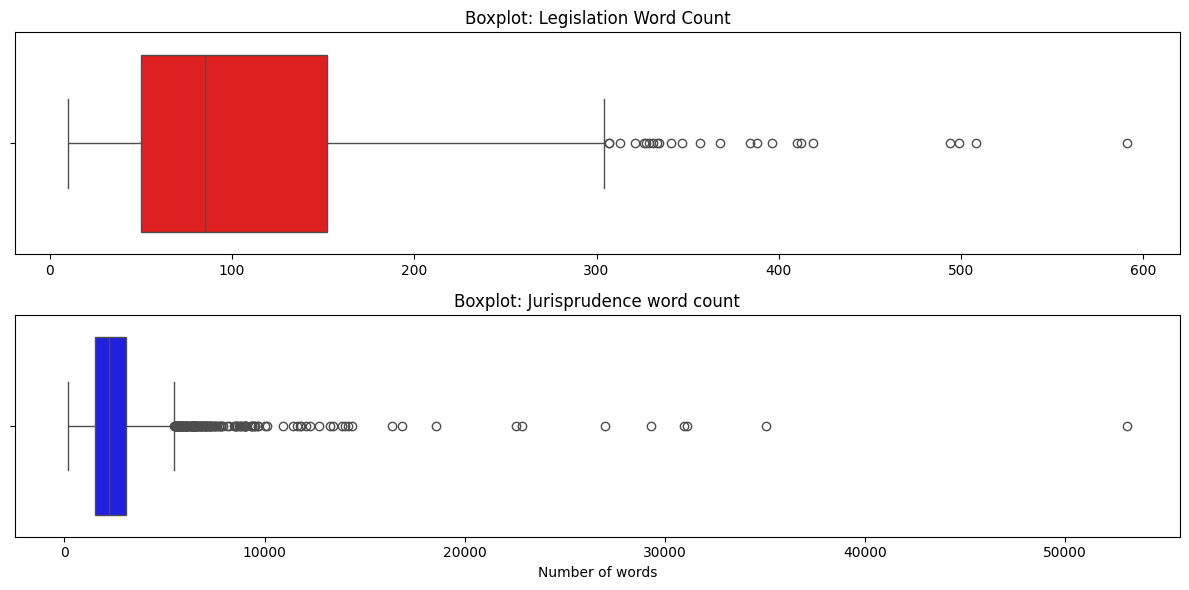

In [65]:
# Boxplot comparison with independent scales
plt.figure(figsize=(12, 6))

# Subplot 1: Legislation
plt.subplot(2, 1, 1)
sns.boxplot(x=df_legislation['word_count'], color='red')
plt.title('Boxplot: Legislation Word Count', fontsize=12)
plt.xlabel('') 

# Subplot 2: Jurisprudence
plt.subplot(2, 1, 2)
sns.boxplot(x=df_jurisprudence['word_count'], color='blue')
plt.title('Boxplot: Jurisprudence word count', fontsize=12)
plt.xlabel('Number of words')

plt.tight_layout()
plt.show()

As shown in the boxplots, the scale of Jurisprudence is nearly 50 times larger than that of Legislation. The outliers in the blue boxplot represent the most complex cases in the corpus.

From a RAG-perspective, these outliers are high-risk documents: they contain too much information for a single LLM context window. This reinforces the decision to use a Split RAG architecture, applying different chunk sizes ($K$) for legislation and jurisprudence to balance precision and context.

### 4.2 Most frequent terms

C:\Users\verkad004\AppData\Local\Temp\ipykernel_22616\1580691633.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_j), y=list(words_j), palette='viridis')


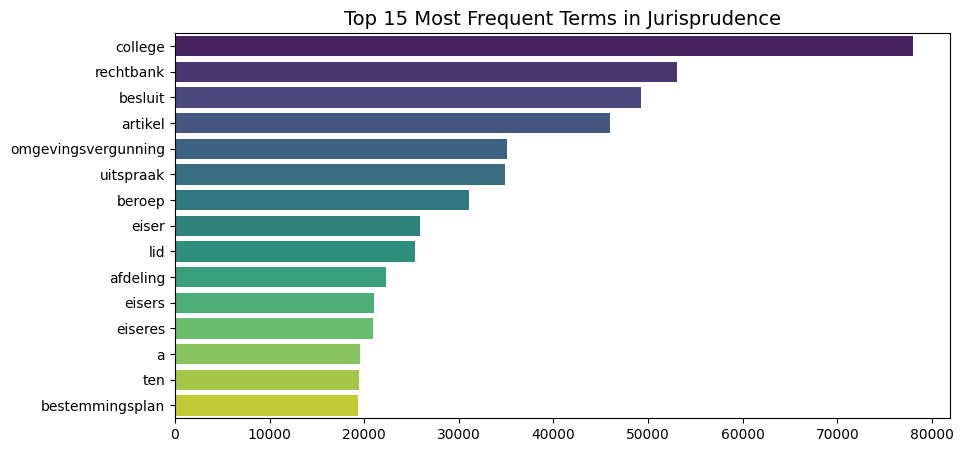

In [71]:
def get_top_words(column, n=15):
    # Load dutch stop words from nltk
    stop_words = stopwords.words('dutch')
    
    
    all_words = ' '.join(column.astype(str)).lower()
    words = re.findall(r'\w+', all_words)
    
    # Search for words not in stopwords and no digits
    meaningful_words = [w for w in words if w not in stop_words and not w.isdigit()]
    return Counter(meaningful_words).most_common(n)

# Plot
top_juris = get_top_words(df_jurisprudence['full_text'])
words_j, counts_j = zip(*top_juris)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts_j), y=list(words_j), palette='viridis')
plt.title('Top 15 Most Frequent Terms in Jurisprudence', fontsize=14)
plt.show()



#### 4.2.1 Findings
The term "college" is the undisputed leader (approx. 80,000 occurrences). This is a vital finding, as it indicates that the vast majority of cases involve the administrative board of a municipality or province as a primary party.Furthermore, the word "artikel" (article) appears frequently. Unlike in standard NLP tasks, where structural words are removed, we have deliberately retained this term. It acts as the main linking pin connecting judicial interpretations to the legislative text of the Omgevingswet.Lastly, terms like "omgevingsvergunning" (environmental permit) and "besluit" (decision) remain high in the ranking, confirming the corpus's focus on the execution of environmental regulations.

### 4.3 Thematic overlap analysis

In [74]:
# Get top 50 most frequent words for both datasets
top_50_juris = get_top_words(df_jurisprudence['full_text'], n=50)
top_50_legis = get_top_words(df_legislation['text'], n=50)

# Extract only the words into sets for comparison
set_juris = set([word for word, count in top_50_juris])
set_legis = set([word for word, count in top_50_legis])

# Identify and sort the common terms (intersection)
overlap = sorted(list(set_juris.intersection(set_legis)))

# Display results
print(f"Number of overlapping terms in top 50: {len(overlap)}")
print(f"Overlapping terms: {', '.join(overlap)}")

Number of overlapping terms in top 50: 15
Overlapping terms: a, aanvraag, afdeling, artikel, b, besluit, binnen, derde, eerste, grond, lid, omgevingsvergunning, ter, toepassing, wet


#### 4.3.1 Findings
The analysis revealed that 15 terms overlapped within the top 50 most frequent words of both datasets. The presence of terms such as 'omgevingsvergunning', 'besluit', and 'artikel' in both corpora confirms a high level of semantic alignment. This indicates that the legislative rules and judicial applications share a common legal vocabulary. These 15 terms function as linking pins. When a user query contains these words, the RAG system is highly likely to retrieve relevant contextual information simultaneously from both the legislation and the jurisprudence. The overlap of structural terms such as 'lid', 'eerste', and 'artikel' highlights the extensive cross-referencing between the two datasets, which is crucial for providing normative legal justifications.



### 4.4 Information density
To determine the optimal chunking strategy for the RAG framework. It is important to analyze the information density of the jurisprudence dataset by measuring the average sentence length.

In [76]:
def get_sentence_stats(text):
    # Split by periods, ignore fragments shorter than 3 words
    sentences = [len(s.split()) for s in str(text).split('.') if len(s.split()) > 2]
    if not sentences:
        return None # Return None to filter out later
    return sentences

# Create a list of all sentence lengths across the entire dataset
all_sentence_lengths = []
for lengths in df_jurisprudence['full_text'].apply(get_sentence_stats):
    if lengths:
        all_sentence_lengths.extend(lengths)

# Calculate statistics
mean_len = np.mean(all_sentence_lengths)
min_len = np.min(all_sentence_lengths)
max_len = np.max(all_sentence_lengths)
std_dev = np.std(all_sentence_lengths)

print(f"Sentence Length Statistics (in words):")
print(f" Mean:   {mean_len:.2f}")
print(f" Min:    {min_len}")
print(f" Max:    {max_len}")
print(f" StdDev: {std_dev:.2f}")

Sentence Length Statistics (in words):
 Mean:   19.63
 Min:    3
 Max:    427
 StdDev: 13.35


#### 4.4.1 Findings
The analysis shows an average sentence length of 19.63 words. This indicates a structurally dense corpus typical of adminstrative law. The range is wide, with sentences spanning from 3 words to a maximum of 427 words. The existence of sentences containing over 400 words confirms that judical reasoning often involves extremely long, nested legal arguments. These sentences contain critical normative justifications that must not be fragmented.

### 5. Multivariate analysis: interaction between metadata and content
In this section, The relation between legal instances (courts) and the complexity (word count) count). of the rulings is examined. This helps to identify whether specific sources require denser chunking.

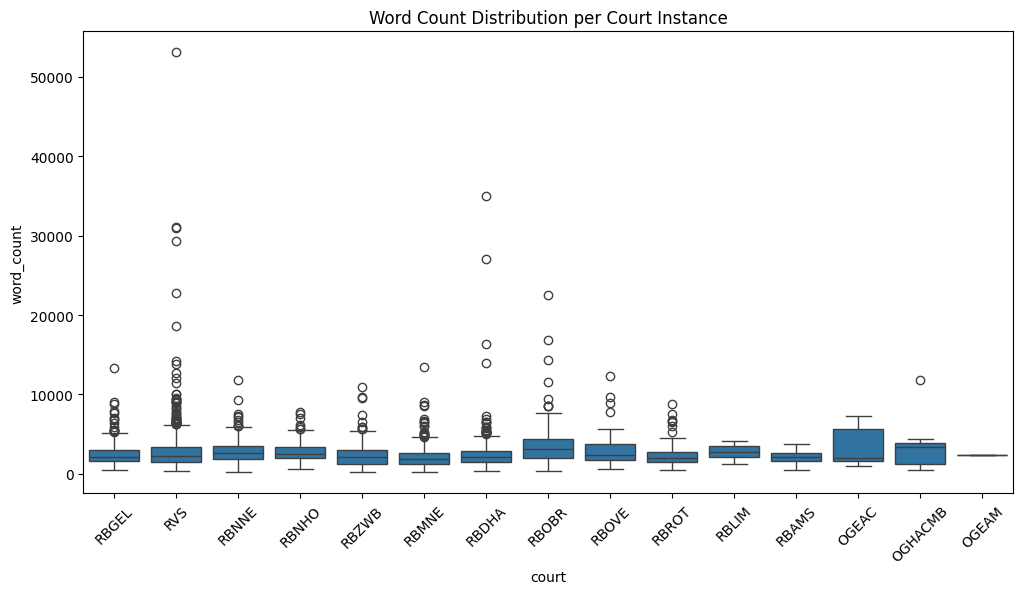

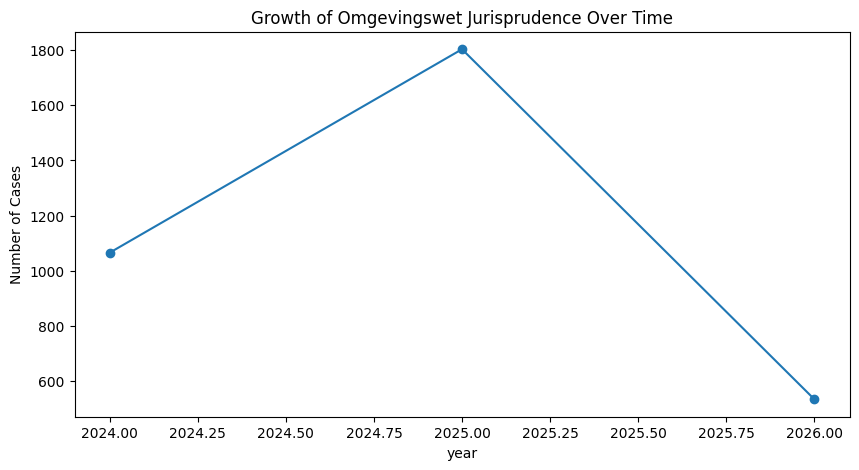

In [66]:
# Relation between court and text length
plt.figure(figsize=(12, 6))
sns.boxplot(x='court', y='word_count', data=df_jurisprudence)
plt.title('Word Count Distribution per Court Instance')
plt.xticks(rotation=45)
plt.show()

# Relation between time and amount of cases
plt.figure(figsize=(10, 5))
df_jurisprudence.groupby('year').size().plot(kind='line', marker='o')
plt.title('Growth of Omgevingswet Jurisprudence Over Time')
plt.ylabel('Number of Cases')
plt.show()

#### 5.1 word count distribution per court instance
The median word count remains relatively consistent across the various courts. This suggests that there is a high level of standardisation in the length of standard or routine judicial rulings within the scope of the Omgevingswet, regardless of the particular court. 

The most significant finding is the high number of outliers, particularly for the Council of State (RVS) and the District Court of The Hague (RBDHA). Although their median values are consistent with those of the other courts, these two courts produce a significant long tail of exceptionally long documents (ranging from 10,000 to over 50,000 words).

The high volume of outliers at the RVS is to be expected, given that it is the highest administrative court handling the most complex environmental appeals. The outliers at the RBDHA likely reflect its role in handling cases of significant national or technical complexity.



#### 5.2 Indentification of anomalies
The line chart shows how frequently judicial cases have been updated over time. This analysis provides insight into the growth of the legal corpus. There is a sharp increase starting from 2024, peaking significantly in 2025. This aligns with the official implementation of the Omgevingswet on 1 January 2024. The high volume of cases in 2024 indicates that the RAG system will primarily be based on the most recent judicial interpretations. This will benefit the system's accuracy as it reflects the current legal standard.


#### 5.3 Metadata ECLI's
The metadata analysis focuses on the jurisdictional attributes of the jurisprudence dataset. These attributes are critical for the "Retrieval" component of the RAG framework.

C:\Users\verkad004\AppData\Local\Temp\ipykernel_22616\2869706905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=court_counts.values, y=court_counts.index, palette='rocket')


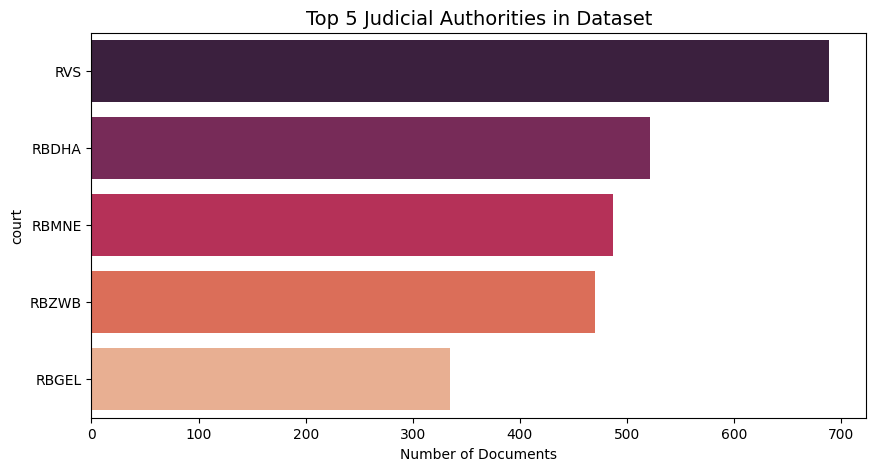

In [70]:
# Metadata Extraction & Analysis
# Extract year from ECLI
df_jurisprudence['year'] = df_jurisprudence['ecli'].str.split(':').str[3]

# Top 5 courts
plt.figure(figsize=(10, 5))
court_counts = df_jurisprudence['court'].value_counts().head(5)
sns.barplot(x=court_counts.values, y=court_counts.index, palette='rocket')
plt.title('Top 5 Judicial Authorities in Dataset', fontsize=14)
plt.xlabel('Number of Documents')
plt.show()

##### 5.3.1 Findings
The dominance of specific courts (e.g., *RVS (Raad van State)* and *RBDHA (Rechtbank Den Haag)*) indicates where the legal weight of the dataset lies. High-level appellate rulings (Raad van State) carry more legal authority than lower court rulings. Every record contains a valid ECLI, which serves as a unique identifier.


### 6. Important findings for methodology
The results of this EDA form the direct foundation for the architectural choices in the RAG framework. Based on the data insights, the following methodological findings have been identified.

#### 6.1 Data filtering and integrity
A total of 502 records were found to contain the placeholder string 'Content not available' instead of actual judicial reasoning. The immediate removal of this noise is essential to ensure that the vector store only contains substantive legal content and to prevent the model from retrieving non-informative placeholders.

#### 6.2 Atomic indexing for legislation
The Legislation dataset is highly consistent and structured, with a median length of 85 words per article. This concise structure allows legislative articles to be indexed as atomic units, preserving the precise legal context without the risk of fragmentation.

#### 6.3 Context-aware chunking for jurisprudence
The Jurisprudence dataset is significantly more complex, with a mean of 2,259 words and extreme outliers exceeding 53,000 words. Sentence analysis shows a mean length of 19.63 words and a maximum of 427 words. These findings justify a larger chunk size (e.g., 1024 tokens) to accommodate the high information density and ensure that long, nested legal arguments remain intact.

#### 6.4 Scale normalization and weighted search
There is a significant scale disparity between legislation (max 591 words) and jurisprudence (max 53,109 words). This necessitates a weighted search strategy to prevent shorter legislative texts from being overshadowed by the sheer volume of jurisprudence during vector retrieval.

#### 6.5 Attribute-Based Metadata Filtering
The dataset's legal weight is concentrated in specific authorities, with the Raad van State (RVS) and Rechtbank Den Haag (RBDHA) being the dominant sources. By indexing ECLI metadata and court types, the RAG architecture can support attribute-based filtering to prioritize high-level appellate rulings or specific timeframes.

#### 6.6 Hybrid search and semantic bridges
The thematic overlap analysis identified 15 key terms shared between the top 50 words of both datasets, including 'omgevingsvergunning', 'besluit', and 'artikel'. These terms function as "linking pins" that justify a Hybrid Search approach, ensuring the system can effectively bridge the gap between statutory rules and judicial interpretations
